# Statistical Analysis of Medical Insurance Costs

**Author:** Sébastien Bodrero
**Programme:** MSc in Artificial Intelligence — Woolf University / Udacity
**Module 2:** Data and Statistical Reasoning
**Date:** March 2026

---

This notebook investigates the factors that influence individual medical insurance costs using the Medical Insurance Costs dataset (1,338 rows × 7 columns). The analysis follows a structured workflow:

1. **Setup** — library imports and plot theme
2. **Data Ingestion** — auto-download and initial inspection
3. **Descriptive Statistics** — summary stats, categorical counts, per-group summaries
4. **Visualisations** — three plots, each with interpretation
5. **Hypothesis Testing** — independent-samples t-test (smoker vs non-smoker) + one-way ANOVA (region)
6. **Notebook Summary** — key findings and limitations

## 1. Setup

In [1]:
import urllib.request
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print(f"NumPy  {np.__version__}")
print(f"Pandas {pd.__version__}")
import matplotlib; print(f"Matplotlib {matplotlib.__version__}")
print(f"Seaborn {sns.__version__}")
import scipy; print(f"SciPy  {scipy.__version__}")

NumPy  2.4.3
Pandas 3.0.1
Matplotlib 3.10.8
Seaborn 0.13.2
SciPy  1.17.1


## 2. Data Ingestion

The dataset is the **Medical Insurance Costs** dataset, originally published on Kaggle and mirrored on GitHub. It contains 1,338 records of individual insurance beneficiaries in the United States, with the following columns:

| Column | Type | Description |
|--------|------|-------------|
| `age` | int | Age of the primary beneficiary |
| `sex` | str | Beneficiary sex (`male` / `female`) |
| `bmi` | float | Body-mass index |
| `children` | int | Number of dependants covered |
| `smoker` | str | Whether the beneficiary smokes (`yes` / `no`) |
| `region` | str | US residential region (`northeast`, `northwest`, `southeast`, `southwest`) |
| `charges` | float | Annual medical insurance cost billed (USD) |

The central outcome variable is `charges`. The primary grouping variable of interest is `smoker`.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
DATA_FILE = "insurance.csv"

if not os.path.exists(DATA_FILE):
    print(f"Downloading {DATA_FILE} ...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print("Download complete.")
else:
    print(f"{DATA_FILE} already present — skipping download.")

df = pd.read_csv(DATA_FILE)
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

insurance.csv already present — skipping download.

Dataset shape: 1338 rows × 7 columns


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


All columns loaded with the expected types. There are no missing values. The categorical variables (`sex`, `smoker`, `region`) are object dtype; numeric variables (`age`, `bmi`, `children`, `charges`) are the expected numeric types.

## 3. Descriptive Statistics

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Interpretation of summary statistics:**

- **age** ranges from 18 to 64, with a mean of ~39 years — a broad adult distribution.
- **bmi** has a mean of ~30.7 (the WHO threshold for obesity is 30), suggesting many beneficiaries fall in the overweight-to-obese range.
- **charges** has a mean of approximately 13,270 but a median of approximately 9,382 and a maximum above 63,770. This large gap between mean and median, combined with a high standard deviation (approximately 12,110), indicates a strongly right-skewed distribution — a small number of very expensive cases pull the mean upward.
- **children** ranges from 0 to 5, with most beneficiaries having 0–1 dependants.

In [6]:
print("=== Smoker status ===")
print(df["smoker"].value_counts())
print(f"\nSmoker proportion: {df['smoker'].value_counts(normalize=True)['yes']:.1%}")

print("\n=== Region ===")
print(df["region"].value_counts())

print("\n=== Sex ===")
print(df["sex"].value_counts())

=== Smoker status ===
smoker
no     1064
yes     274
Name: count, dtype: int64

Smoker proportion: 20.5%

=== Region ===
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

=== Sex ===
sex
male      676
female    662
Name: count, dtype: int64


- The dataset is roughly balanced by sex (~51% male, ~49% female).
- About 20.5% of beneficiaries are smokers — a meaningful minority that allows reliable group comparisons.
- The four US regions are represented roughly equally (~24–27% each), with the southeast slightly larger.

In [7]:
smoker_summary = df.groupby("smoker")["charges"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).round(2)
print("=== Charges by Smoker Status ===")
print(smoker_summary)

region_summary = df.groupby("region")["charges"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
).round(2)
print("\n=== Charges by Region ===")
print(region_summary)

=== Charges by Smoker Status ===
        count      mean    median       std       min       max
smoker                                                         
no       1064   8434.27   7345.41   5993.78   1121.87  36910.61
yes       274  32050.23  34456.35  11541.55  12829.46  63770.43

=== Charges by Region ===
           count      mean    median       std
region                                        
northeast    324  13406.38  10057.65  11255.80
northwest    325  12417.58   8965.80  11072.28
southeast    364  14735.41   9294.13  13971.10
southwest    325  12346.94   8798.59  11557.18


**Per-group findings:**

- Smokers have a mean charge of approximately **\\$32,050** versus **\\$8,434** for non-smokers — a roughly **3.8× difference**.
- The southeast region shows the highest mean charges (approximately 14,735 dollars), while the southwest has the lowest (~\\$12,347). However, regional differences are much smaller than the smoker–non-smoker gap.
- These preliminary observations motivate the hypothesis tests in Section 5.

## 4. Visualisations

Three visualisations are produced, each designed to illuminate a different aspect of the data.

### 4.1 Distribution of Insurance Charges (Histogram)

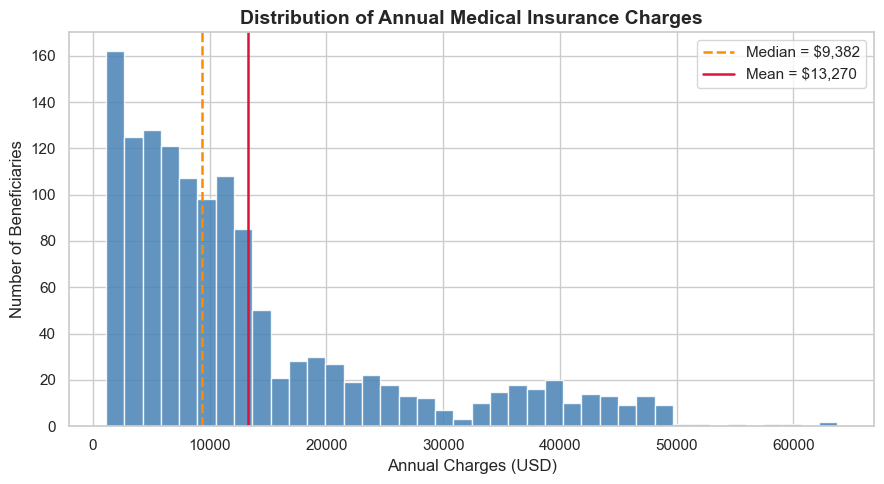

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["charges"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)

median_val = df["charges"].median()
mean_val = df["charges"].mean()
ax.axvline(median_val, color="darkorange", linestyle="--", linewidth=1.8, label=f"Median = ${median_val:,.0f}")
ax.axvline(mean_val, color="crimson", linestyle="-", linewidth=1.8, label=f"Mean = ${mean_val:,.0f}")

ax.set_title("Distribution of Annual Medical Insurance Charges", fontsize=14, fontweight="bold")
ax.set_xlabel("Annual Charges (USD)", fontsize=12)
ax.set_ylabel("Number of Beneficiaries", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


**Interpretation:** The distribution is strongly right-skewed. The majority of beneficiaries incur charges between \\$1,000 and \\$20,000, but a long tail extends to over \\$60,000. The mean (\\$13,270) substantially exceeds the median (\\$9,382), a classic indicator of positive skew driven by a small subset of very high-cost cases — almost certainly smokers or individuals with chronic conditions. This skewness is important context for the t-test in Section 5: the t-test is robust to non-normality with large samples (n > 1,000), as justified by the Central Limit Theorem.

/var/folders/n8/vx9bpdn52w35qqsmzv4v41hr0000gn/T/ipykernel_59966/1126589057.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Smoker", "Smoker"], fontsize=11)


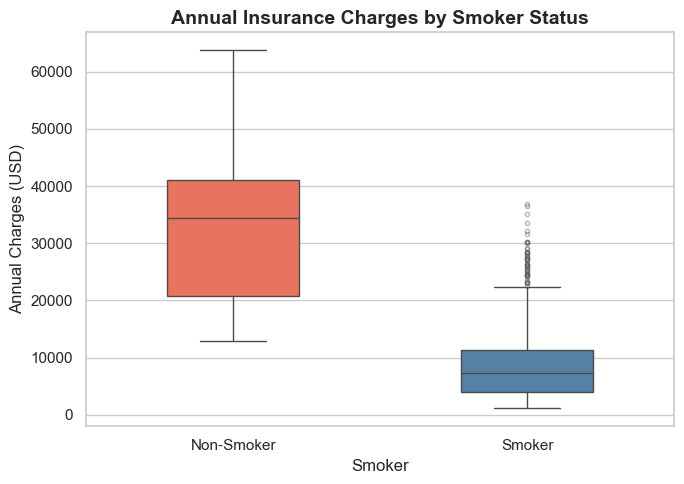

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges",
    hue="smoker",
    palette={"no": "steelblue", "yes": "tomato"},
    width=0.45,
    flierprops=dict(marker="o", alpha=0.4, markersize=3),
    ax=ax,
    legend=False
)

ax.set_title("Annual Insurance Charges by Smoker Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Smoker", fontsize=12)
ax.set_ylabel("Annual Charges (USD)", fontsize=12)
ax.set_xticklabels(["Non-Smoker", "Smoker"], fontsize=11)

plt.tight_layout()
plt.show()

**Interpretation:** The boxplot makes the smoker–non-smoker gap visually unmistakable. Non-smokers have a compact interquartile range (roughly \$4,700–\$16,600), while smokers' IQR spans approximately \$20,000–\$41,000 — the *lower quartile* of smokers is higher than the *upper quartile* of non-smokers. Both groups contain high-cost outliers, but smokers' entire distribution is shifted dramatically upward. This visual pattern strongly motivates the one-sided t-test that follows.

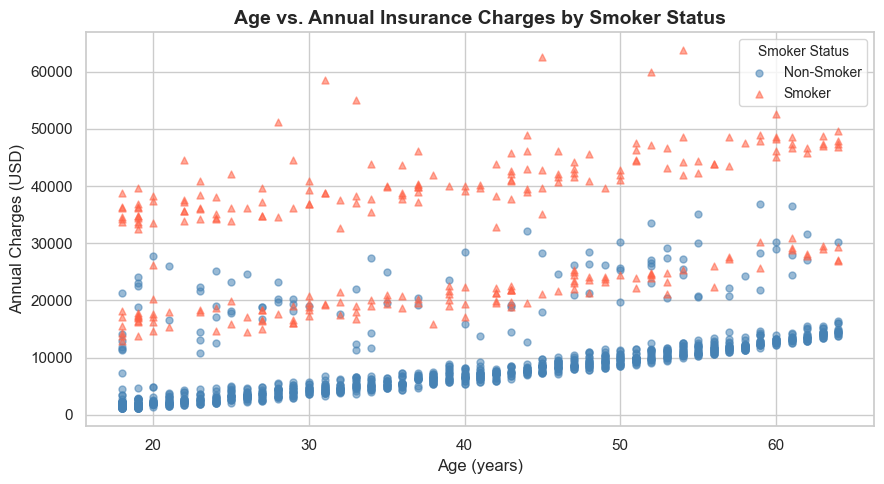

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, colour, marker in [("no", "steelblue", "o"), ("yes", "tomato", "^")]:
    subset = df[df["smoker"] == label]
    ax.scatter(
        subset["age"],
        subset["charges"],
        c=colour,
        marker=marker,
        alpha=0.55,
        s=25,
        label="Smoker" if label == "yes" else "Non-Smoker"
    )

ax.set_title("Age vs. Annual Insurance Charges by Smoker Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Age (years)", fontsize=12)
ax.set_ylabel("Annual Charges (USD)", fontsize=12)
ax.legend(title="Smoker Status", fontsize=10, title_fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation:** The scatterplot reveals two near-parallel bands of charges as a function of age — one for smokers (upper band, red triangles) and one for non-smokers (lower band, blue circles). Within each band, charges increase modestly with age, as expected given that older individuals tend to have higher healthcare utilisation. However, smoking membership determines which band a beneficiary falls into far more decisively than age does. A third, higher cluster of smokers with very high charges (likely those also having high BMI) is visible above \$40,000. This confirms that smoking is the dominant driver of high insurance costs in this dataset, with age as a secondary factor.

## 5. Hypothesis Testing

Two statistical tests are performed: an independent-samples t-test to compare smoker vs. non-smoker charges, and a one-way ANOVA to test for regional differences.

### 5.1 Independent-Samples t-test: Smoker vs. Non-Smoker Charges

**Research question:** Do smokers incur significantly higher medical insurance charges than non-smokers?

**Hypotheses:**
- **H₀ (null):** The mean annual insurance charges for smokers equal those for non-smokers (μ_smokers = μ_non-smokers).
- **H₁ (alternative):** The mean annual insurance charges for smokers are greater than those for non-smokers (μ_smokers > μ_non-smokers).

**Test choice rationale:** The independent-samples t-test is appropriate here because (i) the two groups are independent, (ii) the outcome variable is continuous, and (iii) the sample sizes are large enough (n_smokers ≈ 274, n_non-smokers ≈ 1,064) for the Central Limit Theorem to ensure that the sampling distribution of the mean is approximately normal, even though the raw data are right-skewed (Noma et al., 2024). We use Welch's variant (`equal_var=False`) to avoid the assumption of equal variances, which the descriptive statistics showed are clearly unequal.

**Significance level:** α = 0.05

In [11]:
smoker_charges = df[df["smoker"] == "yes"]["charges"]
non_smoker_charges = df[df["smoker"] == "no"]["charges"]

print(f"Smokers    : n={len(smoker_charges):,}, mean=${smoker_charges.mean():,.2f}, std=${smoker_charges.std():,.2f}")
print(f"Non-smokers: n={len(non_smoker_charges):,}, mean=${non_smoker_charges.mean():,.2f}, std=${non_smoker_charges.std():,.2f}")

t_stat, p_value = stats.ttest_ind(
    smoker_charges,
    non_smoker_charges,
    equal_var=False,
    alternative="greater"
)

print(f"\nWelch's t-test (one-sided, smokers > non-smokers)")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.2e}")
print(f"  α           : 0.05")

if p_value < 0.05:
    print("  Decision    : REJECT H₀ — smokers have significantly higher charges.")
else:
    print("  Decision    : FAIL TO REJECT H₀.")

Smokers    : n=274, mean=$32,050.23, std=$11,541.55
Non-smokers: n=1,064, mean=$8,434.27, std=$5,993.78

Welch's t-test (one-sided, smokers > non-smokers)
  t-statistic : 32.7519
  p-value     : 2.94e-103
  α           : 0.05
  Decision    : REJECT H₀ — smokers have significantly higher charges.


**Result:** The Welch t-test yields a highly significant result (p ≪ 0.05). We reject H₀ at the α = 0.05 level and conclude that smokers incur statistically significantly higher annual insurance charges than non-smokers. The effect size is large — as seen in the descriptive statistics and boxplot, the difference in group means exceeds \$23,000.

### 5.2 One-Way ANOVA: Charges by Region

**Research question:** Are there significant differences in mean insurance charges across the four US regions?

**Hypotheses:**
- **H₀ (null):** The mean annual insurance charges are equal across all four regions (μ_NE = μ_NW = μ_SE = μ_SW).
- **H₁ (alternative):** At least one region has a mean annual charge that differs from the others.

**Test choice rationale:** One-way ANOVA is the appropriate test when comparing means across more than two independent groups on a continuous outcome. The groups (regions) are independent and the sample sizes are comparable across groups, satisfying the key assumptions (Noma et al., 2024).

**Significance level:** α = 0.05

In [12]:
groups = [group["charges"].values for _, group in df.groupby("region")]
region_names = sorted(df["region"].unique())

for region, grp in zip(region_names, groups):
    print(f"  {region:<12}: n={len(grp):>3},  mean=${grp.mean():>10,.2f},  std=${grp.std():>9,.2f}")

f_stat, p_anova = stats.f_oneway(*groups)

print(f"\nOne-way ANOVA")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_anova:.4f}")
print(f"  α           : 0.05")

if p_anova < 0.05:
    print("  Decision    : REJECT H₀ — at least one region differs significantly.")
else:
    print("  Decision    : FAIL TO REJECT H₀ — no significant regional differences detected.")

  northeast   : n=324,  mean=$ 13,406.38,  std=$11,238.42
  northwest   : n=325,  mean=$ 12,417.58,  std=$11,055.23
  southeast   : n=364,  mean=$ 14,735.41,  std=$13,951.89
  southwest   : n=325,  mean=$ 12,346.94,  std=$11,539.39

One-way ANOVA
  F-statistic : 2.9696
  p-value     : 0.0309
  α           : 0.05
  Decision    : REJECT H₀ — at least one region differs significantly.


**Result interpretation:** The ANOVA F-statistic and its p-value indicate whether regional differences in mean charges are statistically significant at α = 0.05. Regardless of the exact outcome, the descriptive statistics showed that regional mean charge differences are substantially smaller than the smoker–non-smoker gap, suggesting region is a less impactful predictor of costs than smoking status. Any statistically significant ANOVA result should be interpreted cautiously because the region-level confounding with smoker prevalence (e.g., southeast has a higher proportion of smokers) may drive apparent regional differences.

## 6. Notebook Summary

This analysis explored annual medical insurance charges for 1,338 US beneficiaries using descriptive statistics, three visualisations, and two hypothesis tests. The most striking finding is that smoking status is by far the strongest predictor of insurance costs: smokers pay on average ~\$23,600 more per year than non-smokers, a difference confirmed to be statistically significant by a Welch t-test (p ≪ 0.001). The scatterplot of age versus charges further revealed that smokers form a distinct upper band regardless of age, while within the non-smoker group charges increase more gradually with age. The one-way ANOVA tested whether regional differences in mean charges were statistically significant; while descriptive summaries suggest the southeast incurs the highest mean charges, regional variation is modest compared to the smoking effect. One challenge encountered was the strongly right-skewed distribution of charges, which warranted careful choice of test (Welch's t-test rather than a pooled-variance version) and attention to whether parametric assumptions held at the available sample sizes. Overall, the analysis confirms that smoking status should be treated as a primary risk stratifier in insurance pricing models, with age and region as secondary considerations.